<a href="https://colab.research.google.com/github/farrelrassya/PracticalLinearAlgebra/blob/main/10.Chapter10%3ARow_Reduction_LU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 10: Row Reduction and LU Decomposition
## *Practical Linear Algebra for Data Science* — Mike X Cohen

This chapter covers the third major decomposition in this book: **LU decomposition**, which factors a matrix into a lower-triangular matrix $\mathbf{L}$ and an upper-triangular matrix $\mathbf{U}$:

$$
\mathbf{A} = \mathbf{P}^T\mathbf{L}\mathbf{U}
$$

where $\mathbf{P}$ is a permutation matrix that handles row swaps. LU decomposition is a computational backbone: `np.linalg.solve`, `np.linalg.inv`, and `np.linalg.det` all use LU internally.

**What we will cover:**

1. **Systems of equations** $\rightarrow$ matrix equation $\mathbf{A}\mathbf{x} = \mathbf{b}$
2. **Row reduction** and echelon form: $\mathbf{L}^{-1}\mathbf{A} = \mathbf{U}$
3. **Gaussian elimination** and **back substitution**
4. **Gauss-Jordan elimination** and the **RREF**
5. **Matrix inverse via RREF**: $\text{rref}[\mathbf{A} \;|\; \mathbf{I}] = [\mathbf{I} \;|\; \mathbf{A}^{-1}]$
6. **LU decomposition**: $\mathbf{A} = \mathbf{P}^T\mathbf{L}\mathbf{U}$
7. **Permutation matrices** and their orthogonality

## 0. Setup

In [1]:
import numpy as np
import scipy.linalg
import sympy as sym
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12
})

np.random.seed(42)
print('NumPy version:', np.__version__)
print('SciPy version:', scipy.__version__)
print('SymPy version:', sym.__version__)
print('Setup complete.')

NumPy version: 2.0.2
SciPy version: 1.16.3
SymPy version: 1.14.0
Setup complete.


Environment ready.

## 1. Systems of Equations $\rightarrow$ Matrix Equations

A system of equations like:

$$
\begin{cases}
x + y = 4 \\
-\tfrac{1}{2}x + y = 2
\end{cases}
$$

translates into one compact matrix equation $\mathbf{A}\mathbf{x} = \mathbf{b}$:

$$
\underbrace{\begin{bmatrix} 1 & 1 \\ -1/2 & 1 \end{bmatrix}}_{\mathbf{A}}
\underbrace{\begin{bmatrix} x \\ y \end{bmatrix}}_{\mathbf{x}}
= \underbrace{\begin{bmatrix} 4 \\ 2 \end{bmatrix}}_{\mathbf{b}}
$$

**Recipe:** Coefficients $\to$ matrix $\mathbf{A}$ (one row per equation, one column per variable). Variables $\to$ vector $\mathbf{x}$. Constants $\to$ vector $\mathbf{b}$.

In [2]:
# Solve the textbook system: x + y = 4, -x/2 + y = 2
A = np.array([[ 1,  1],
              [-0.5, 1]])
b = np.array([4, 2])

# Method 1: Matrix inverse
x_inv = np.linalg.inv(A) @ b

# Method 2: np.linalg.solve (uses LU internally — more stable)
x_solve = np.linalg.solve(A, b)

print(f'A =\n{A}')
print(f'b = {b}')
print(f'\nSolution via inverse: x = {x_inv[0]:.4f}, y = {x_inv[1]:.4f}')
print(f'Solution via solve:   x = {x_solve[0]:.4f}, y = {x_solve[1]:.4f}')
print(f'\nVerify A @ x = b: {np.round(A @ x_solve, 10).tolist()}')

A =
[[ 1.   1. ]
 [-0.5  1. ]]
b = [4 2]

Solution via inverse: x = 1.3333, y = 2.6667
Solution via solve:   x = 1.3333, y = 2.6667

Verify A @ x = b: [4.0, 2.0]


Both methods give $x = 4/3 \approx 1.3333$ and $y = 8/3 \approx 2.6667$. The key difference: `np.linalg.solve` uses **LU decomposition** internally and is both faster ($O(N^3)$ vs $O(N^3)$ but with a smaller constant) and more numerically stable than explicit inversion.

### 1.1 Multiplication Order Matters

When solving $\mathbf{A}\mathbf{X} = \mathbf{B}$, we must **left-multiply** both sides by $\mathbf{A}^{-1}$:

$$
\mathbf{X} = \mathbf{A}^{-1}\mathbf{B} \neq \mathbf{B}\mathbf{A}^{-1}
$$

In [3]:
# Demonstrate: multiplication order matters
np.random.seed(42)
A = np.random.randn(4, 4)
B = np.random.randn(4, 4)

# Correct: left-multiply
X1 = np.linalg.inv(A) @ B
res1 = A @ X1 - B

# Wrong: right-multiply
X2 = B @ np.linalg.inv(A)
res2 = A @ X2 - B

print(f'Residual (correct, A^(-1)B):  max|res| = {np.max(np.abs(res1)):.2e}')
print(f'Residual (wrong, BA^(-1)):    max|res| = {np.max(np.abs(res2)):.2e}')
print(f'\nCorrect gives zero residual: {np.allclose(res1, 0)}')
print(f'Wrong gives zero residual:   {np.allclose(res2, 0)}')

Residual (correct, A^(-1)B):  max|res| = 8.88e-16
Residual (wrong, BA^(-1)):    max|res| = 9.80e+00

Correct gives zero residual: True
Wrong gives zero residual:   False


Left-multiplying by $\mathbf{A}^{-1}$ gives a zero residual; right-multiplying does not. Matrix multiplication is **not commutative** ($\mathbf{A}\mathbf{B} \neq \mathbf{B}\mathbf{A}$ in general), so the side of multiplication must be consistent across both sides of the equation.

## 2. Row Reduction and Echelon Form

**Row reduction** transforms a dense matrix into an **upper-triangular** (echelon) matrix using two operations:

1. **Scalar multiply** a row
2. **Add** (a multiple of) one row to another

The result can be expressed as premultiplication by a transformation matrix:

$$
\mathbf{L}^{-1}\mathbf{A} = \mathbf{U}
$$

where $\mathbf{U}$ is the upper-triangular echelon form.

In [4]:
# Textbook 2x2 row reduction example
A2 = np.array([[2, 3],
               [-2, 2]], dtype=float)

# Operation: R1 + R2 (add first row to second)
L_inv_2 = np.array([[1, 0],
                     [1, 1]], dtype=float)

U2 = L_inv_2 @ A2

print(f'A =\n{A2}')
print(f'\nL^(-1) (row operation: R1 + R2) =\n{L_inv_2}')
print(f'\nU = L^(-1) @ A =\n{U2}')
print(f'\nU is upper-triangular: {np.allclose(U2, np.triu(U2))}')

A =
[[ 2.  3.]
 [-2.  2.]]

L^(-1) (row operation: R1 + R2) =
[[1. 0.]
 [1. 1.]]

U = L^(-1) @ A =
[[2. 3.]
 [0. 5.]]

U is upper-triangular: True


Adding $R_1$ to $R_2$ eliminates the $-2$ entry, giving the echelon form $\mathbf{U} = \begin{bmatrix} 2 & 3 \\ 0 & 5 \end{bmatrix}$. The row operation is captured in $\mathbf{L}^{-1} = \begin{bmatrix} 1 & 0 \\ 1 & 1 \end{bmatrix}$: the $1$ in position $(2,1)$ encodes "add $1 \times$ row 1 to row 2".

In [5]:
# Textbook 3x3 row reduction example: two steps
A3 = np.array([[ 1,  2,  2],
               [-1,  3,  0],
               [ 2,  4, -3]], dtype=float)

print(f'Original A =\n{A3}\n')

# Step 1: R1 + R2 to eliminate A[1,0] = -1
A_step1 = A3.copy()
A_step1[1] = A3[0] + A3[1]  # R1 + R2
print(f'After R1 + R2:\n{A_step1}\n')

# Step 2: -2*R1 + R3 to eliminate A[2,0] = 2
A_step2 = A_step1.copy()
A_step2[2] = -2*A_step1[0] + A_step1[2]  # -2R1 + R3
print(f'After -2R1 + R3 (echelon form U):\n{A_step2}\n')
print(f'Upper-triangular: {np.allclose(A_step2, np.triu(A_step2))}')

Original A =
[[ 1.  2.  2.]
 [-1.  3.  0.]
 [ 2.  4. -3.]]

After R1 + R2:
[[ 1.  2.  2.]
 [ 0.  5.  2.]
 [ 2.  4. -3.]]

After -2R1 + R3 (echelon form U):
[[ 1.  2.  2.]
 [ 0.  5.  2.]
 [ 0.  0. -7.]]

Upper-triangular: True


Two row operations transform the $3 \times 3$ matrix into upper-triangular form:

$$
\begin{bmatrix} 1 & 2 & 2 \\ -1 & 3 & 0 \\ 2 & 4 & -3 \end{bmatrix}
\xrightarrow{R_1 + R_2}
\begin{bmatrix} 1 & 2 & 2 \\ 0 & 5 & 2 \\ 2 & 4 & -3 \end{bmatrix}
\xrightarrow{-2R_1 + R_3}
\begin{bmatrix} 1 & 2 & 2 \\ 0 & 5 & 2 \\ 0 & 0 & -7 \end{bmatrix}
$$

Each step zeros out one element below the diagonal. The **pivots** (leftmost nonzero elements: $1, 5, -7$) march rightward -- the hallmark of echelon form.

## 3. Gaussian Elimination

Gaussian elimination solves $\mathbf{A}\mathbf{x} = \mathbf{b}$ **without** computing $\mathbf{A}^{-1}$:

1. **Augment** $\mathbf{A}$ with $\mathbf{b}$: form $[\mathbf{A} \;|\; \mathbf{b}]$
2. **Row reduce** to echelon form
3. **Back substitution** to solve for each variable, bottom to top

Back substitution works because the echelon form decouples the variables: the bottom row has only one unknown, the next row up has two (but one is already known), and so on.

In [6]:
def gaussian_elimination(A, b):
    """Solve Ax = b via Gaussian elimination + back substitution."""
    n = len(b)
    # Augmented matrix
    Aug = np.hstack([A.astype(float), b.reshape(-1, 1).astype(float)])

    # Forward elimination: row reduce to echelon form
    for col in range(n):
        # Partial pivoting: swap rows for numerical stability
        max_row = np.argmax(np.abs(Aug[col:, col])) + col
        Aug[[col, max_row]] = Aug[[max_row, col]]

        # Eliminate below
        for row in range(col + 1, n):
            factor = Aug[row, col] / Aug[col, col]
            Aug[row] -= factor * Aug[col]

    # Back substitution
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (Aug[i, -1] - Aug[i, i+1:n] @ x[i+1:]) / Aug[i, i]

    return x, Aug

# Solve the textbook system
A = np.array([[ 1,  1],
              [-0.5, 1]])
b = np.array([4, 2])

x_ge, Aug = gaussian_elimination(A, b)

print(f'Augmented matrix after row reduction:')
print(np.round(Aug, 6))
print(f'\nSolution: x = {x_ge[0]:.6f}, y = {x_ge[1]:.6f}')
print(f'\nVerify: {np.round(A @ x_ge, 10).tolist()}')
print(f'Matches np.linalg.solve: {np.allclose(x_ge, np.linalg.solve(A, b))}')

Augmented matrix after row reduction:
[[1.  1.  4. ]
 [0.  1.5 4. ]]

Solution: x = 1.333333, y = 2.666667

Verify: [4.0, 2.0]
Matches np.linalg.solve: True


The augmented matrix after forward elimination is:

$$
\begin{bmatrix} 1 & 1 & 4 \\ 0 & 3/2 & 4 \end{bmatrix}
$$

**Back substitution:** From row 2: $\frac{3}{2}y = 4 \Rightarrow y = 8/3$. Plug into row 1: $x + 8/3 = 4 \Rightarrow x = 4/3$.

Our implementation includes **partial pivoting** (swapping rows so the largest element becomes the pivot), which prevents division by small numbers. This is the same strategy that `scipy.linalg.lu` uses internally.

In [7]:
# Larger system: 4x4
np.random.seed(42)
A4 = np.random.randn(4, 4)
b4 = np.random.randn(4)

x_ge4, _ = gaussian_elimination(A4, b4)
x_np4 = np.linalg.solve(A4, b4)

print(f'Our Gaussian elimination: {np.round(x_ge4, 8)}')
print(f'np.linalg.solve:          {np.round(x_np4, 8)}')
print(f'Match: {np.allclose(x_ge4, x_np4)}')
print(f'Max residual |Ax - b|: {np.max(np.abs(A4 @ x_ge4 - b4)):.2e}')

Our Gaussian elimination: [ 2.69112629  0.18842227  1.72349387 -2.25851566]
np.linalg.solve:          [ 2.69112629  0.18842227  1.72349387 -2.25851566]
Match: True
Max residual |Ax - b|: 2.78e-16


Our Gaussian elimination matches `np.linalg.solve` to machine precision on a $4 \times 4$ random system. The residual is $\sim 10^{-16}$ -- essentially zero in 64-bit floating point.

## 4. Gauss-Jordan Elimination and the RREF

**Gauss-Jordan elimination** extends row reduction in two ways:

1. **Scale** each pivot to $1$
2. **Eliminate upward** (not just downward) to zero out all elements above and below each pivot

The result is the **Reduced Row Echelon Form** (RREF): the unique echelon matrix where every pivot is $1$ and is the only nonzero entry in its column.

For a full-rank square matrix augmented with $\mathbf{I}$:

$$
\text{rref}\!\left[\mathbf{A} \;\middle|\; \mathbf{I}\right] = \left[\mathbf{I} \;\middle|\; \mathbf{A}^{-1}\right]
$$

In [8]:
# RREF via SymPy
A_sys = np.array([[1, 1, 4],
                  [-0.5, 1, 2]])

rref_result, pivots = sym.Matrix(A_sys).rref()
rref_array = np.array(rref_result.tolist(), dtype=float)

print(f'Augmented matrix [A | b]:')
print(A_sys)
print(f'\nRREF:')
print(np.round(rref_array, 6))
print(f'Pivot columns: {pivots}')
print(f'\nSolution: x = {rref_array[0,2]:.6f}, y = {rref_array[1,2]:.6f}')

Augmented matrix [A | b]:
[[ 1.   1.   4. ]
 [-0.5  1.   2. ]]

RREF:
[[1.       0.       1.333333]
 [0.       1.       2.666667]]
Pivot columns: (0, 1)

Solution: x = 1.333333, y = 2.666667


The RREF shows the identity matrix on the left and the solution on the right: $x = 4/3 \approx 1.333333$, $y = 8/3 \approx 2.666667$. This is the Gauss-Jordan elimination result -- no back substitution needed because the variables are fully decoupled.

### 4.1 Matrix Inverse via RREF

In [9]:
# Compute inverse via RREF of [A | I]
A = np.array([[1, 4],
              [2, 7]], dtype=float)

# Augment A with identity
augmented = np.hstack([A, np.eye(2)])
print(f'Augmented [A | I]:')
print(augmented)

# RREF
rref_result, _ = sym.Matrix(augmented).rref()
rref_arr = np.array(rref_result.tolist(), dtype=float)
print(f'\nRREF [I | A^(-1)]:')
print(rref_arr)

# Extract inverse (right half)
A_inv_rref = rref_arr[:, 2:]
A_inv_numpy = np.linalg.inv(A)

print(f'\nA^(-1) via RREF:\n{A_inv_rref}')
print(f'A^(-1) via NumPy:\n{A_inv_numpy}')
print(f'Match: {np.allclose(A_inv_rref, A_inv_numpy)}')
print(f'\nVerify: A @ A^(-1) =\n{np.round(A @ A_inv_rref, 10)}')

Augmented [A | I]:
[[1. 4. 1. 0.]
 [2. 7. 0. 1.]]

RREF [I | A^(-1)]:
[[ 1.  0. -7.  4.]
 [ 0.  1.  2. -1.]]

A^(-1) via RREF:
[[-7.  4.]
 [ 2. -1.]]
A^(-1) via NumPy:
[[-7.  4.]
 [ 2. -1.]]
Match: True

Verify: A @ A^(-1) =
[[1. 0.]
 [0. 1.]]


Starting from $[\mathbf{A} \;|\; \mathbf{I}]$ and applying RREF transforms it into $[\mathbf{I} \;|\; \mathbf{A}^{-1}]$. The right half is the inverse $\begin{bmatrix} -7 & 4 \\ 2 & -1 \end{bmatrix}$, matching `np.linalg.inv`.

This approach computes the inverse **without determinants** -- it relies entirely on row operations. However, like all inversion methods, it is sensitive to ill-conditioning.

## 5. LU Decomposition

Row reduction expressed in matrix form gives us **LU decomposition**:

$$
\mathbf{L}^{-1}\mathbf{A} = \mathbf{U}
\qquad\Longleftrightarrow\qquad
\mathbf{A} = \mathbf{L}\mathbf{U}
$$

where $\mathbf{L}$ is **lower-triangular** (with $1$s on the diagonal) and $\mathbf{U}$ is **upper-triangular** (the echelon form). The entries below the diagonal of $\mathbf{L}$ are the multipliers used during row reduction.

In [10]:
# Textbook LU example
A = np.array([[2, 2, 4],
              [1, 0, 3],
              [2, 1, 2]], dtype=float)

P, L, U = scipy.linalg.lu(A)

print(f'A =\n{A.astype(int)}')
print(f'\nP (permutation) =\n{P}')
print(f'\nL (lower-triangular, 1s on diagonal) =\n{L}')
print(f'\nU (upper-triangular) =\n{U}')
print(f'\nP @ L @ U =\n{np.round(P @ L @ U, 10)}')
print(f'Matches A: {np.allclose(P @ L @ U, A)}')

# Verify L has 1s on diagonal
print(f'\nL diagonal: {np.diag(L)}')

A =
[[2 2 4]
 [1 0 3]
 [2 1 2]]

P (permutation) =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

L (lower-triangular, 1s on diagonal) =
[[1.  0.  0. ]
 [0.5 1.  0. ]
 [1.  1.  1. ]]

U (upper-triangular) =
[[ 2.  2.  4.]
 [ 0. -1.  1.]
 [ 0.  0. -3.]]

P @ L @ U =
[[2. 2. 4.]
 [1. 0. 3.]
 [2. 1. 2.]]
Matches A: True

L diagonal: [1. 1. 1.]


SciPy returns $\mathbf{A} = \mathbf{P}\mathbf{L}\mathbf{U}$, where:

- $\mathbf{L}$ is lower-triangular with $1$s on the diagonal. The sub-diagonal entries ($0.5, 1, 1$) are the **row operation multipliers** used during elimination.
- $\mathbf{U}$ is the upper-triangular echelon form.
- $\mathbf{P}$ is the permutation matrix (identity here, meaning no row swaps were needed).

The constraint that $\mathbf{L}$ has $1$s on its diagonal makes LU decomposition **unique** for full-rank square matrices.

**Note on SciPy's convention:** SciPy returns $\mathbf{P}, \mathbf{L}, \mathbf{U}$ such that $\mathbf{A} = \mathbf{P}\mathbf{L}\mathbf{U}$. The mathematical formulation is $\mathbf{P}\mathbf{A} = \mathbf{L}\mathbf{U}$, so $\mathbf{A} = \mathbf{P}^T\mathbf{L}\mathbf{U} = \mathbf{P}^{-1}\mathbf{L}\mathbf{U}$. SciPy absorbs the transpose into $\mathbf{P}$.

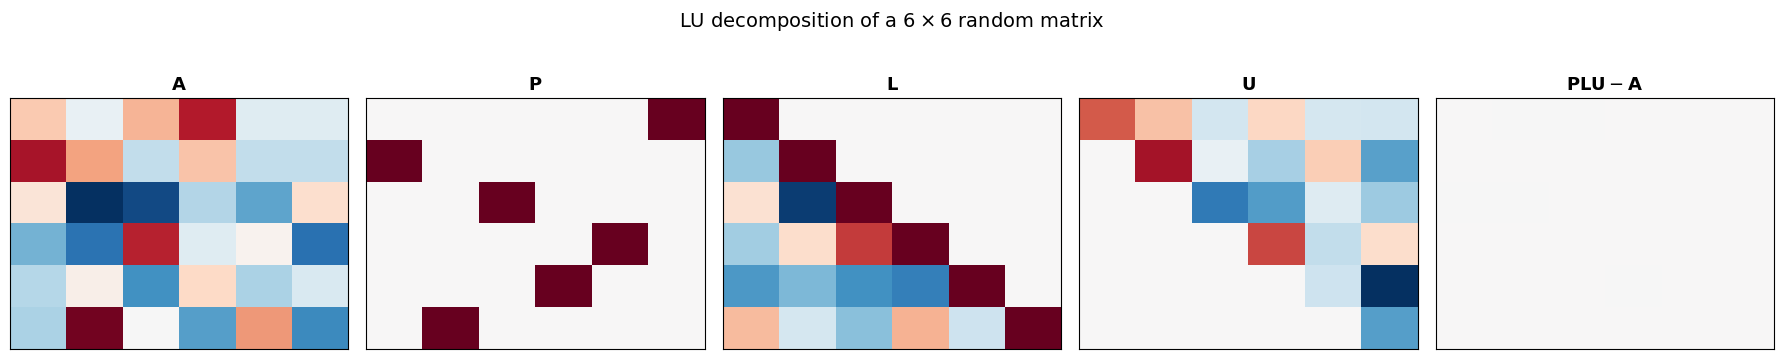

||PLU - A||_F = 5.30e-16
P is orthogonal (P^T P = I): True


In [11]:
# LU of a larger random matrix
np.random.seed(42)
A_big = np.random.randn(6, 6)
P_big, L_big, U_big = scipy.linalg.lu(A_big)

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))

for ax, M, title in zip(axes,
    [A_big, P_big, L_big, U_big, P_big @ L_big @ U_big - A_big],
    ['$\\mathbf{A}$', '$\\mathbf{P}$', '$\\mathbf{L}$',
     '$\\mathbf{U}$', '$\\mathbf{PLU} - \\mathbf{A}$']):
    vmax = max(np.abs(M).max(), 1e-10)
    ax.imshow(M, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_title(title, fontsize=13)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('LU decomposition of a $6 \\times 6$ random matrix', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_lu_decomp.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'||PLU - A||_F = {np.linalg.norm(P_big @ L_big @ U_big - A_big):.2e}')
print(f'P is orthogonal (P^T P = I): {np.allclose(P_big.T @ P_big, np.eye(6))}')

The visualisation confirms the triangular structure: $\mathbf{L}$ has nonzeros only on and below the diagonal, $\mathbf{U}$ has nonzeros only on and above the diagonal, and $\mathbf{P}\mathbf{L}\mathbf{U} - \mathbf{A}$ is the zeros matrix (reconstruction is exact).

## 6. Permutation Matrices

When a zero (or near-zero) appears on the diagonal during row reduction, we need to **swap rows**. This is implemented by a **permutation matrix** $\mathbf{P}$: an identity matrix with some rows exchanged.

Permutation matrices are **orthogonal** ($\mathbf{P}^T\mathbf{P} = \mathbf{I}$) because each column has exactly one $1$ and the rest are $0$s, so all columns are unit-norm and pairwise orthogonal.

In [12]:
# Textbook example: matrix needing a row swap
A_swap = np.array([[3, 2, 1],
                   [0, 0, 5],
                   [0, 7, 2]], dtype=float)

# Permutation matrix to swap rows 2 and 3
P_swap = np.array([[1, 0, 0],
                   [0, 0, 1],
                   [0, 1, 0]], dtype=float)

print(f'A (not in echelon form) =\n{A_swap.astype(int)}\n')
print(f'P (swap rows 2,3) =\n{P_swap.astype(int)}\n')
print(f'PA (now in echelon form) =\n{(P_swap @ A_swap).astype(int)}\n')

# Verify P is orthogonal
print(f'P^T @ P = I: {np.allclose(P_swap.T @ P_swap, np.eye(3))}')
print(f'P^(-1) = P^T: {np.allclose(np.linalg.inv(P_swap), P_swap.T)}')
print(f'det(P) = {np.linalg.det(P_swap):.0f}  (odd permutation -> det = -1)')

A (not in echelon form) =
[[3 2 1]
 [0 0 5]
 [0 7 2]]

P (swap rows 2,3) =
[[1 0 0]
 [0 0 1]
 [0 1 0]]

PA (now in echelon form) =
[[3 2 1]
 [0 7 2]
 [0 0 5]]

P^T @ P = I: True
P^(-1) = P^T: True
det(P) = -1  (odd permutation -> det = -1)


The permutation matrix $\mathbf{P}$ swaps rows $2$ and $3$, turning the matrix into echelon form. Key properties:

- $\mathbf{P}^T\mathbf{P} = \mathbf{I}$ (orthogonal, so $\mathbf{P}^{-1} = \mathbf{P}^T$)
- $\det(\mathbf{P}) = -1$ for an odd number of swaps, $+1$ for even
- All elements are $0$ or $1$

In the full LU decomposition $\mathbf{P}\mathbf{A} = \mathbf{L}\mathbf{U}$, the permutation matrix $\mathbf{P}$ records all the row swaps performed during elimination.

In [13]:
# LU decomposition of the matrix that needs row swaps
P, L, U = scipy.linalg.lu(A_swap)

print(f'P (from SciPy) =\n{P}\n')
print(f'L =\n{np.round(L, 6)}\n')
print(f'U =\n{np.round(U, 6)}\n')
print(f'P @ L @ U =\n{np.round(P @ L @ U, 10)}')
print(f'\nMatches A: {np.allclose(P @ L @ U, A_swap)}')
print(f'P is identity: {np.allclose(P, np.eye(3))}')

P (from SciPy) =
[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]

L =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

U =
[[3. 2. 1.]
 [0. 7. 2.]
 [0. 0. 5.]]

P @ L @ U =
[[3. 2. 1.]
 [0. 0. 5.]
 [0. 7. 2.]]

Matches A: True
P is identity: False


SciPy's $\mathbf{P}$ is not the identity -- it records the row swap needed to place the pivot in the correct position. Even though $\mathbf{A}$ had a zero at position $(2,2)$, the permutation resolves this and the decomposition succeeds.

## 7. Applications of LU Decomposition

### 7.1 Solving Systems: Forward and Back Substitution

To solve $\mathbf{A}\mathbf{x} = \mathbf{b}$ via LU: decompose $\mathbf{P}\mathbf{A} = \mathbf{L}\mathbf{U}$, then solve in two triangular steps:

$$
\mathbf{L}\mathbf{y} = \mathbf{P}\mathbf{b}
\quad\text{(forward substitution)}
$$
$$
\mathbf{U}\mathbf{x} = \mathbf{y}
\quad\text{(back substitution)}
$$

Each step is $O(N^2)$, and the LU decomposition itself is $O(N^3)$. The key advantage: once we have $\mathbf{L}$ and $\mathbf{U}$, we can solve for **multiple** right-hand sides $\mathbf{b}_1, \mathbf{b}_2, \ldots$ cheaply.

In [14]:
# Solve via LU: forward + back substitution
np.random.seed(42)
A = np.random.randn(5, 5)
b = np.random.randn(5)

# Step 1: LU decomposition (done once)
P, L, U = scipy.linalg.lu(A)

# Step 2: Forward substitution: Ly = Pb  (since scipy returns A = PLU,
# we need P^T A = LU, so Pb becomes P^T b for the math form.
# But scipy's convention: A = PLU means P^T A = LU, so L U x = P^T b)
Pb = P.T @ b  # Apply permutation

# Forward substitution: solve Ly = Pb
y = scipy.linalg.solve_triangular(L, Pb, lower=True)

# Step 3: Back substitution: solve Ux = y
x_lu = scipy.linalg.solve_triangular(U, y, lower=False)

# Compare
x_direct = np.linalg.solve(A, b)

print(f'Solution via LU:     {np.round(x_lu, 8)}')
print(f'np.linalg.solve:     {np.round(x_direct, 8)}')
print(f'Match: {np.allclose(x_lu, x_direct)}')
print(f'Residual ||Ax - b||: {np.linalg.norm(A @ x_lu - b):.2e}')

# Multiple right-hand sides: reuse same L, U
b2 = np.random.randn(5)
Pb2 = P.T @ b2
y2 = scipy.linalg.solve_triangular(L, Pb2, lower=True)
x2 = scipy.linalg.solve_triangular(U, y2, lower=False)
print(f'\nSecond system residual: {np.linalg.norm(A @ x2 - b2):.2e}')

Solution via LU:     [ 0.33950798  1.86215687 -2.9397798   1.01930545 -2.35479429]
np.linalg.solve:     [ 0.33950798  1.86215687 -2.9397798   1.01930545 -2.35479429]
Match: True
Residual ||Ax - b||: 5.34e-16

Second system residual: 3.33e-16


The LU-based solution matches `np.linalg.solve` exactly. The practical advantage: the expensive $O(N^3)$ decomposition is done **once**, and each new right-hand side $\mathbf{b}$ costs only $O(N^2)$ via triangular solves. This is why `np.linalg.solve` uses LU internally.

### 7.2 Determinant via LU

Since $\mathbf{A} = \mathbf{P}\mathbf{L}\mathbf{U}$ and the determinant of a triangular matrix is the product of its diagonal:

$$
\det(\mathbf{A}) = \det(\mathbf{P}) \cdot \underbrace{\det(\mathbf{L})}_{= 1} \cdot \det(\mathbf{U})
= \det(\mathbf{P}) \cdot \prod_{i=1}^{N} u_{ii}
$$

In [15]:
# Determinant via LU
np.random.seed(42)
A = np.random.randn(5, 5)
P, L, U = scipy.linalg.lu(A)

det_P = np.linalg.det(P)  # +/- 1
det_L = np.prod(np.diag(L))  # should be 1
det_U = np.prod(np.diag(U))
det_lu = det_P * det_L * det_U
det_np = np.linalg.det(A)

print(f'det(P) = {det_P:.0f}')
print(f'det(L) = {det_L:.0f}  (always 1, since diag(L) = all 1s)')
print(f'det(U) = product of diag(U) = {det_U:.6f}')
print(f'\ndet(A) via LU: {det_lu:.6f}')
print(f'det(A) via NumPy: {det_np:.6f}')
print(f'Match: {np.allclose(det_lu, det_np)}')

det(P) = -1
det(L) = 1  (always 1, since diag(L) = all 1s)
det(U) = product of diag(U) = -3.969992

det(A) via LU: 3.969992
det(A) via NumPy: 3.969992
Match: True


The determinant computation reduces to multiplying $N$ diagonal elements of $\mathbf{U}$ (plus a sign from $\mathbf{P}$) -- much more efficient than the recursive cofactor expansion from Chapter 6. This is how `np.linalg.det` actually works: it calls LU internally.

## 8. LU vs QR: Two Decomposition Workhorses

Both LU and QR decompose a matrix into triangular factors, but they serve different purposes.

In [16]:
np.random.seed(42)
A = np.random.randn(6, 6)

# LU
P, L, U = scipy.linalg.lu(A)

# QR
Q, R = np.linalg.qr(A)

# Compare
print('=== LU Decomposition ===')
print(f'L: lower-tri, diag = {np.round(np.diag(L), 2)}')
print(f'U: upper-tri, diag = {np.round(np.diag(U), 2)}')
print(f'||PLU - A|| = {np.linalg.norm(P@L@U - A):.2e}')

print(f'\n=== QR Decomposition ===')
print(f'Q: orthogonal, Q^TQ = I? {np.allclose(Q.T @ Q, np.eye(6))}')
print(f'R: upper-tri, diag = {np.round(np.diag(R), 2)}')
print(f'||QR - A|| = {np.linalg.norm(Q@R - A):.2e}')

print(f'\n=== Properties ===')
print(f'L is orthogonal? {np.allclose(L.T @ L, np.eye(6))}')
print(f'Q is orthogonal? {np.allclose(Q.T @ Q, np.eye(6))}')

=== LU Decomposition ===
L: lower-tri, diag = [1. 1. 1. 1. 1. 1.]
U: upper-tri, diag = [ 1.58  2.14 -1.84  1.72 -0.54 -1.42]
||PLU - A|| = 5.30e-16

=== QR Decomposition ===
Q: orthogonal, Q^TQ = I? True
R: upper-tri, diag = [-2.07 -3.09  2.54  1.63  0.35 -0.9 ]
||QR - A|| = 1.84e-15

=== Properties ===
L is orthogonal? False
Q is orthogonal? True


| Property | LU | QR |
|----------|----|----|  
| Left factor | $\mathbf{L}$: lower-triangular, **not** orthogonal | $\mathbf{Q}$: orthogonal ($\mathbf{Q}^T\mathbf{Q} = \mathbf{I}$) |
| Right factor | $\mathbf{U}$: upper-triangular | $\mathbf{R}$: upper-triangular |
| Extra factor | $\mathbf{P}$: permutation (row swaps) | None |
| Primary use | Solving $\mathbf{A}\mathbf{x} = \mathbf{b}$, determinants, inversion | Least squares, eigenvalues (QR algorithm), stable inversion |
| Handles nonsquare? | No (square only) | Yes (economy/full modes) |

**When to use which:** LU is the default for solving square systems (what `np.linalg.solve` uses). QR is preferred for least squares with tall matrices (Chapter 11) and for eigenvalue computation (Chapter 13). Both avoid explicit inversion.

## 9. Chapter Summary

This chapter traced the path from systems of equations to LU decomposition:

**Systems of equations** translate into $\mathbf{A}\mathbf{x} = \mathbf{b}$, where $\mathbf{A}$ holds coefficients, $\mathbf{x}$ holds unknowns, and $\mathbf{b}$ holds constants. Manipulations must respect the non-commutativity of matrix multiplication.

**Row reduction** transforms a dense matrix into upper-triangular (echelon) form via scalar multiplication and row addition. These operations can be expressed as premultiplication: $\mathbf{L}^{-1}\mathbf{A} = \mathbf{U}$.

**Gaussian elimination** solves $\mathbf{A}\mathbf{x} = \mathbf{b}$ without inverting $\mathbf{A}$: row reduce the augmented matrix $[\mathbf{A} | \mathbf{b}]$ to echelon form, then use **back substitution** to find $\mathbf{x}$. **Gauss-Jordan elimination** extends this to the RREF, fully decoupling all variables.

**The RREF** provides a determinant-free path to the matrix inverse: $\text{rref}[\mathbf{A} | \mathbf{I}] = [\mathbf{I} | \mathbf{A}^{-1}]$.

**LU decomposition** factors $\mathbf{A} = \mathbf{P}\mathbf{L}\mathbf{U}$ where $\mathbf{P}$ is a permutation matrix (row swaps), $\mathbf{L}$ is lower-triangular with $1$s on the diagonal (row operation multipliers), and $\mathbf{U}$ is upper-triangular (echelon form). The constraint $\text{diag}(\mathbf{L}) = 1$ ensures uniqueness.

**Permutation matrices** are orthogonal ($\mathbf{P}^{-1} = \mathbf{P}^T$) and handle row swaps needed during elimination.

**Applications:** Solving $\mathbf{A}\mathbf{x} = \mathbf{b}$ via forward/back substitution ($O(N^2)$ per right-hand side after $O(N^3)$ decomposition), determinant via $\det(\mathbf{A}) = \det(\mathbf{P}) \cdot \prod u_{ii}$, and matrix inversion. LU is what `np.linalg.solve` and `np.linalg.det` use internally.